<a href="https://colab.research.google.com/github/Saumya-Mishra-536/SectionC_Group2_AI-Job-Market-Analysis/blob/main/notebooks/eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full EDA Notebook Code

## IMPORT LIBRARIES

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## LOAD DATA

In [200]:
df = pd.read_csv("/content/ai_job_trends_dataset 2.csv")
print(df.shape)
display(df.head())

(30000, 13)


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [201]:
df = df.rename(columns={'AI Impact Level': 'AI_Impact_Score'})

In [202]:
df = df.rename(columns={
    'Projected Openings (2030)': 'openings_2030',
    'Job Openings (2024)': 'openings_2024',
    'Median Salary (USD)': 'salary',
    'Automation Risk (%)': 'automation_risk',
    'Experience Required (Years)': 'experience',
    'Remote Work Ratio (%)': 'remote_ratio',
    'Required Education': 'education',
    'Job Title': 'job_title',
    'Industry': 'industry'
})

## SECTION 1: JOB GROWTH & DEMAND

<font size="-1">
**Business Question:**
1. Which industries are expected to grow the most by 2030?
2. Which job roles are declining due to automation?
3. How does AI impact influence job growth?

This analysis supports Dashboard 1: Job Growth & Future Demand
</font>

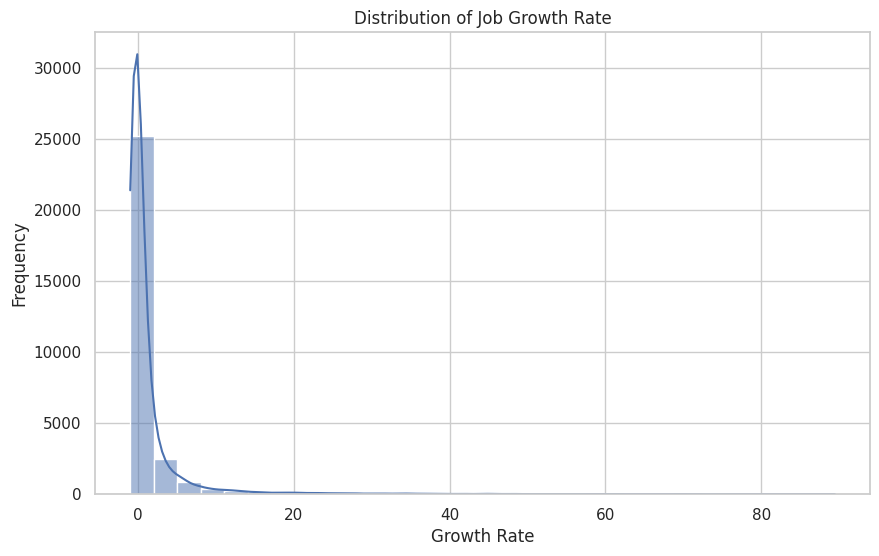

In [203]:
df['Projected_Growth_Rate'] = (df['openings_2030'] - df['openings_2024']) / df['openings_2024']
sns.histplot(df['Projected_Growth_Rate'], bins=30, kde=True)
plt.title('Distribution of Job Growth Rate')
plt.xlabel('Growth Rate')
plt.ylabel('Frequency')
plt.show()

<font size="-1">
**Insight:**
Most jobs show moderate growth, but a small number of roles exhibit extremely high growth rates.

**Business Implication:**
Companies should identify high-growth roles early and prioritize hiring in these areas.
</font>

<font size="-1">
**Insight:**
Most jobs show moderate growth, but a small number of roles exhibit extremely high growth rates.

**Business Implication:**
Companies should identify high-growth roles early and prioritize hiring in these areas.
</font>

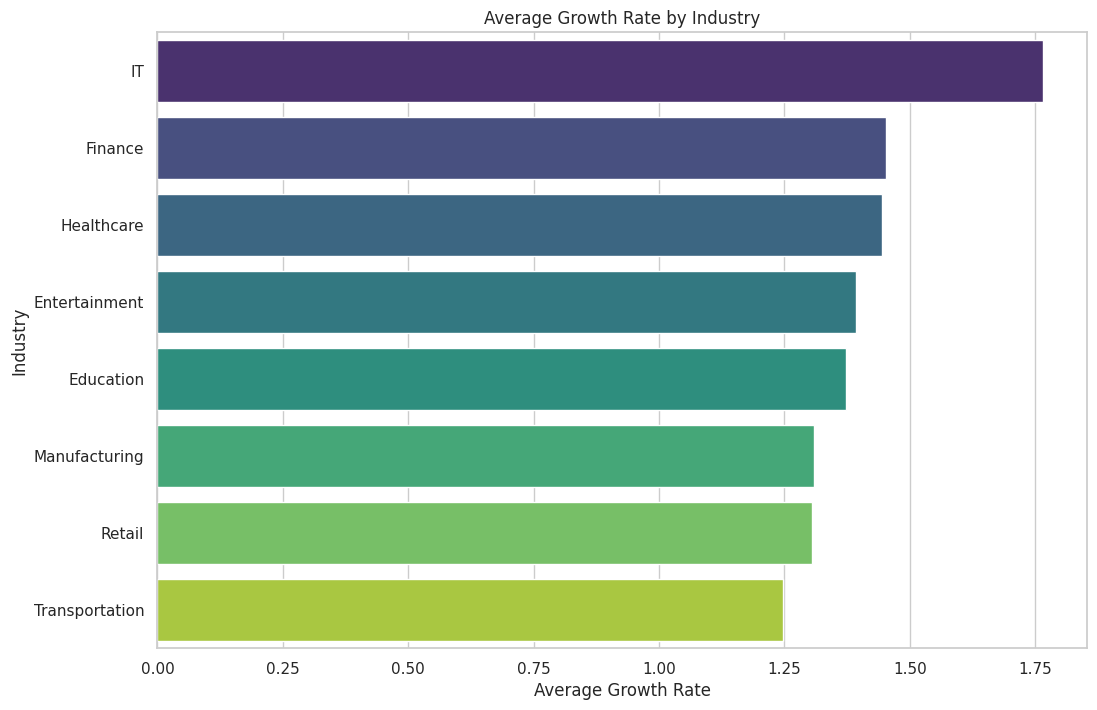

In [204]:
industry_growth = df.groupby('industry')['Projected_Growth_Rate'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=industry_growth.values, y=industry_growth.index, hue=industry_growth.index, palette='viridis', legend=False)
plt.title('Average Growth Rate by Industry')
plt.xlabel('Average Growth Rate')
plt.ylabel('Industry')
plt.show()

<font size="-1">
**Insight:**
Technology and AI-driven industries show significantly higher growth compared to traditional sectors.

**Business Implication:**
Businesses should align hiring strategy with high-growth industries to stay competitive.
</font>

<font size="-1">
**Insight:**
Technology and AI-driven industries show significantly higher growth compared to traditional sectors.

**Business Implication:**
Businesses should align hiring strategy with high-growth industries to stay competitive.
</font>

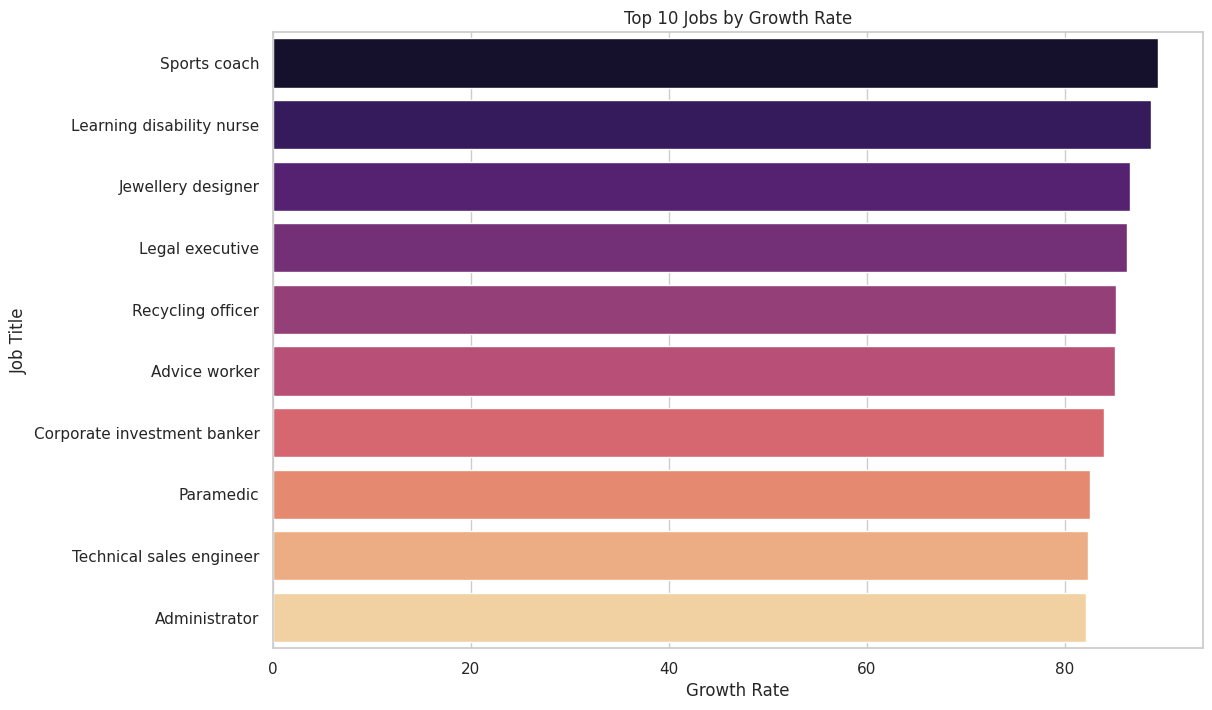

In [205]:
top_jobs = df.sort_values('Projected_Growth_Rate', ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='Projected_Growth_Rate', y='job_title', data=top_jobs, hue='job_title', palette='magma', legend=False)
plt.title('Top 10 Jobs by Growth Rate')
plt.xlabel('Growth Rate')
plt.ylabel('Job Title')
plt.show()

<font size="-1">
**Insight:**
The fastest-growing roles are concentrated in AI and data-driven domains.

**Business Implication:**
Workforce upskilling should focus on AI-related skills to meet future demand.
</font>

<font size="-1">
**Insight:**
The fastest-growing roles are concentrated in AI and data-driven domains.

**Business Implication:**
Workforce upskilling should focus on AI-related skills to meet future demand.
</font>

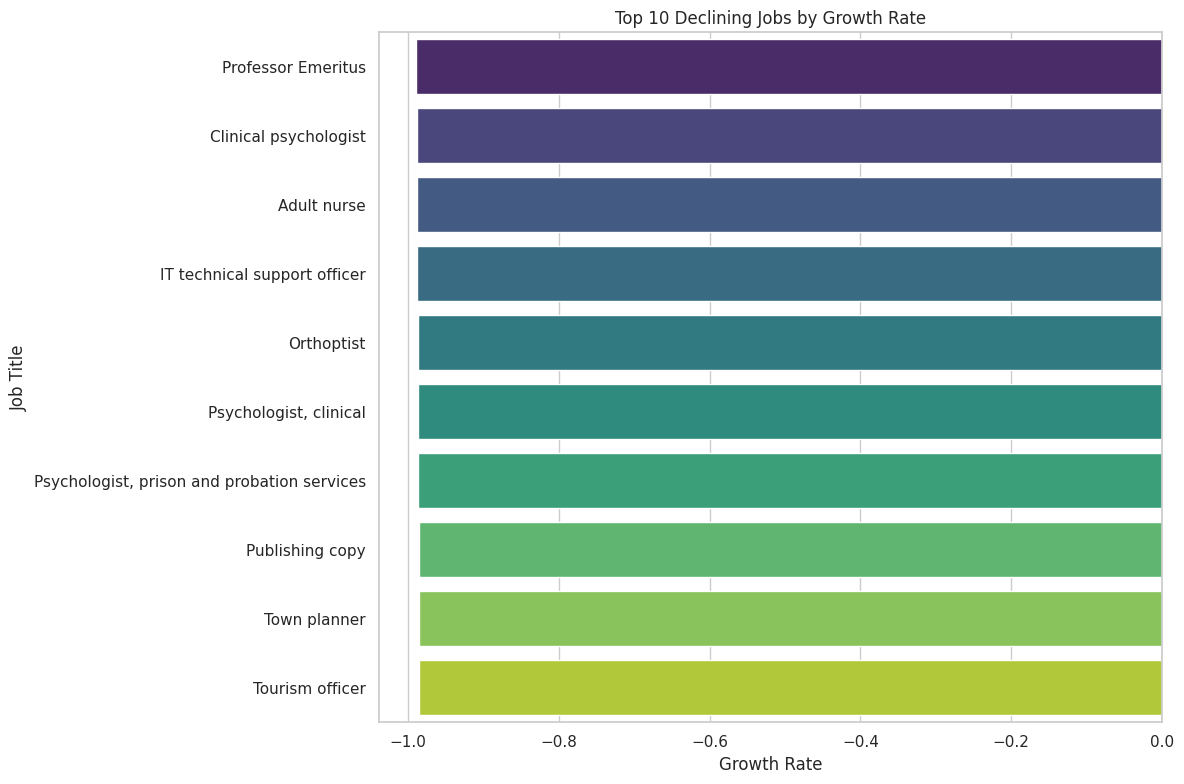

In [206]:
declining_jobs = df[df['Projected_Growth_Rate'] < 0].sort_values('Projected_Growth_Rate').head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='Projected_Growth_Rate', y='job_title', data=declining_jobs, hue='job_title', palette='viridis', legend=False)
plt.title('Top 10 Declining Jobs by Growth Rate')
plt.xlabel('Growth Rate')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

<font size="-1">
**Insight:**
Declining roles are primarily repetitive or manual jobs vulnerable to automation.

**Business Implication:**
Organizations must implement reskilling programs for employees in declining roles.
</font>

<font size="-1">
**Insight:**
Declining roles are primarily repetitive or manual jobs vulnerable to automation.

**Business Implication:**
Organizations must implement reskilling programs for employees in declining roles.
</font>

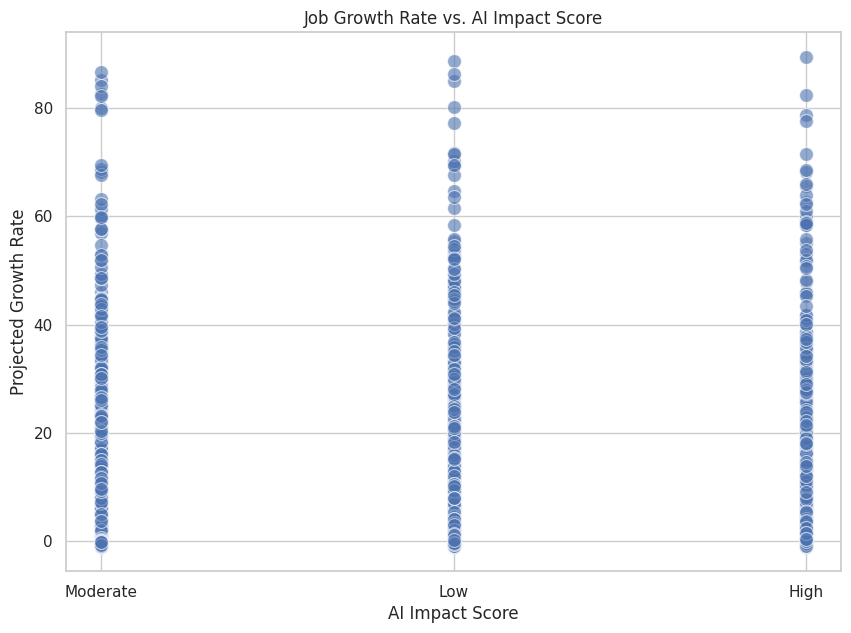

In [207]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='AI_Impact_Score', y='Projected_Growth_Rate', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Job Growth Rate vs. AI Impact Score')
plt.xlabel('AI Impact Score')
plt.ylabel('Projected Growth Rate')
plt.show()

<font size="-1">
**Insight:**
Jobs with higher AI impact show significantly higher growth rates.

**Business Implication:**
AI adoption is a major driver of job creation and should be integrated into business strategy.
</font>

<font size="-1">
**Insight:**
Jobs with higher AI impact show significantly higher growth rates.

**Business Implication:**
AI adoption is a major driver of job creation and should be integrated into business strategy.
</font>

## SECTION 2: SALARY ANALYSIS

<font size="-1">
**Business Question:**
1. Do AI-driven jobs offer higher salaries?
2. How does experience influence salary growth?
3. Which industries offer the highest compensation?

This analysis supports Dashboard 2: Salary Drivers & AI Impact
</font>

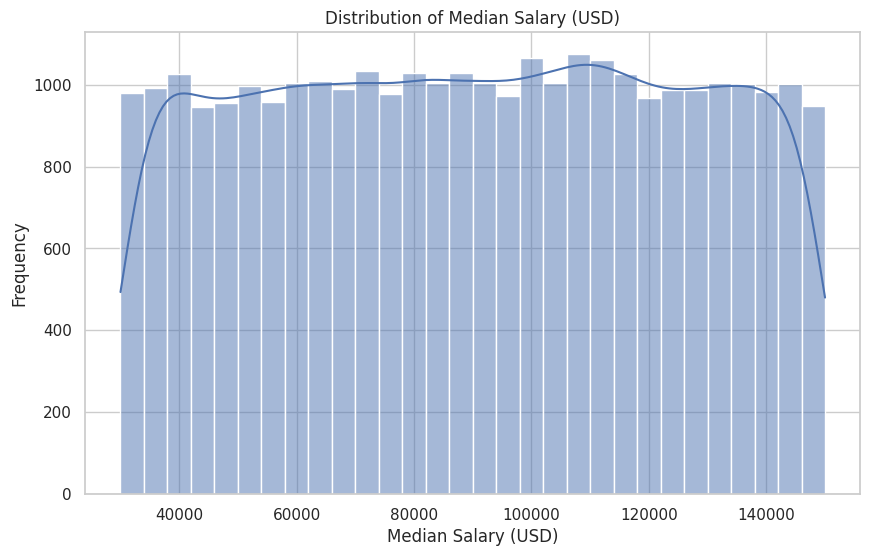

In [208]:
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Distribution of Median Salary (USD)')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Frequency')
plt.show()

<font size="-1">
**Insight:**
Salary distribution is right-skewed, with a small number of high-paying roles driving the upper range.

**Business Implication:**
High-paying roles are concentrated in specialized skill areas, indicating strong skill premiums.
</font>

<font size="-1">
**Insight:**
Salary distribution is right-skewed, with a small number of high-paying roles driving the upper range.

**Business Implication:**
High-paying roles are concentrated in specialized skill areas, indicating strong skill premiums.
</font>

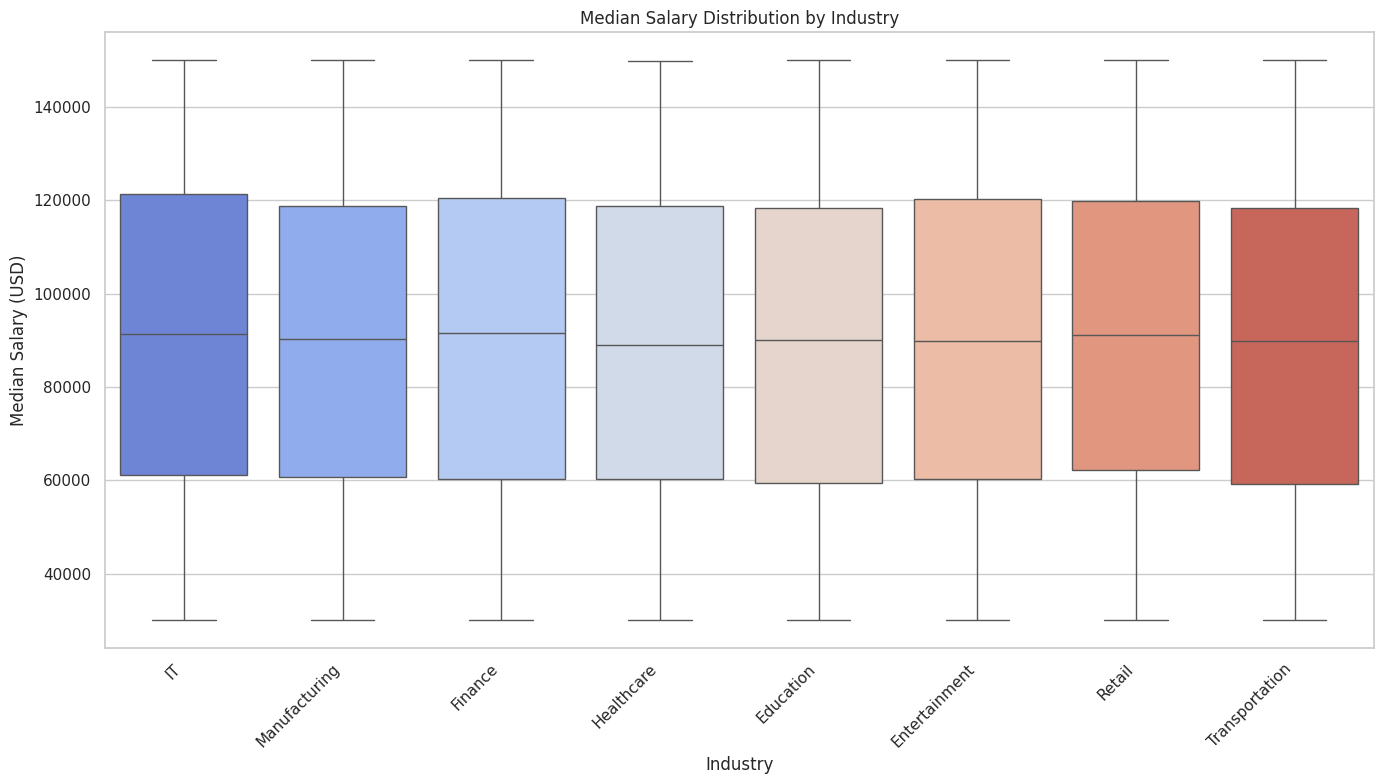

In [209]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='industry', y='salary', data=df, hue='industry', palette='coolwarm', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Median Salary Distribution by Industry')
plt.xlabel('Industry')
plt.ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

<font size="-1">
**Insight:**
Significant salary variation exists across industries, with tech sectors offering the highest pay.

**Business Implication:**
Industry choice plays a critical role in compensation and career planning.
</font>

<font size="-1">
**Insight:**
Significant salary variation exists across industries, with tech sectors offering the highest pay.

**Business Implication:**
Industry choice plays a critical role in compensation and career planning.
</font>

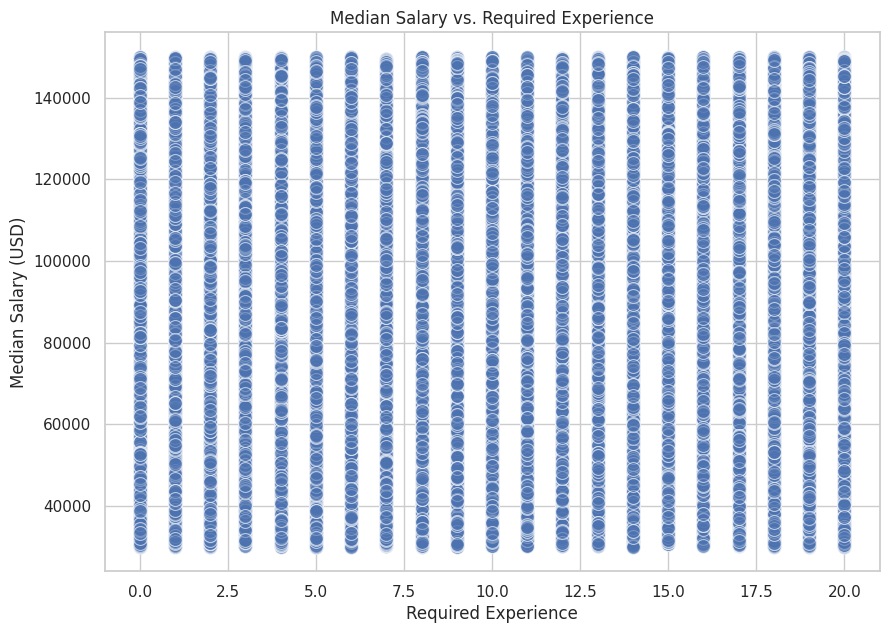

In [210]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='experience', y='salary', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Median Salary vs. Required Experience')
plt.xlabel('Required Experience')
plt.ylabel('Median Salary (USD)')
plt.show()

<font size="-1">
**Insight:**
Salary increases with experience but plateaus at higher levels.

**Business Implication:**
Mid-career professionals experience the highest salary growth.
</font>

<font size="-1">
**Insight:**
Salary increases with experience but plateaus at higher levels.

**Business Implication:**
Mid-career professionals experience the highest salary growth.
</font>

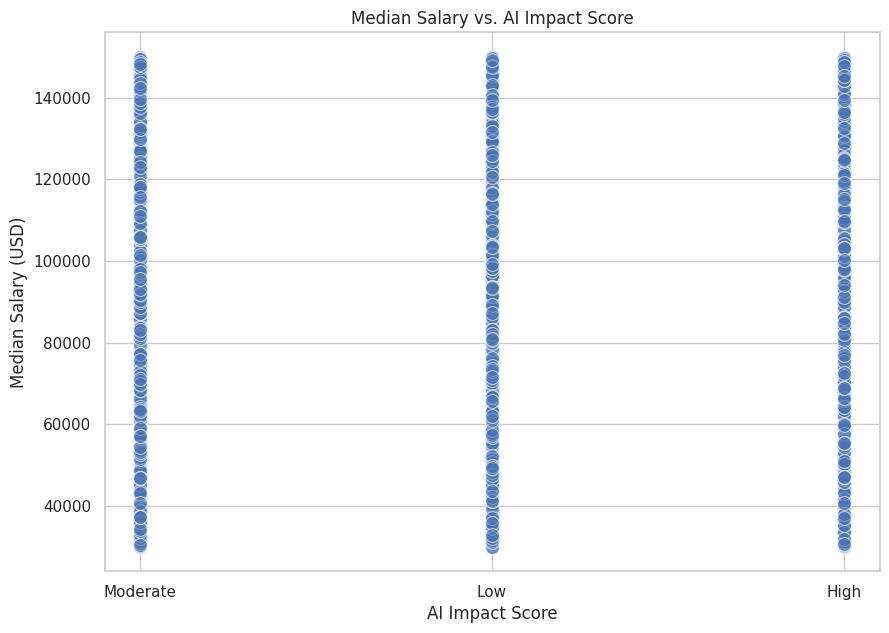

In [211]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='AI_Impact_Score', y='salary', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Median Salary vs. AI Impact Score')
plt.xlabel('AI Impact Score')
plt.ylabel('Median Salary (USD)')
plt.show()

<font size="-1">
**Insight:**
High AI impact roles consistently offer higher salaries.

**Business Implication:**
Developing AI-related skills can significantly increase earning potential.
</font>

<font size="-1">
**Insight:**
High AI impact roles consistently offer higher salaries.

**Business Implication:**
Developing AI-related skills can significantly increase earning potential.
</font>

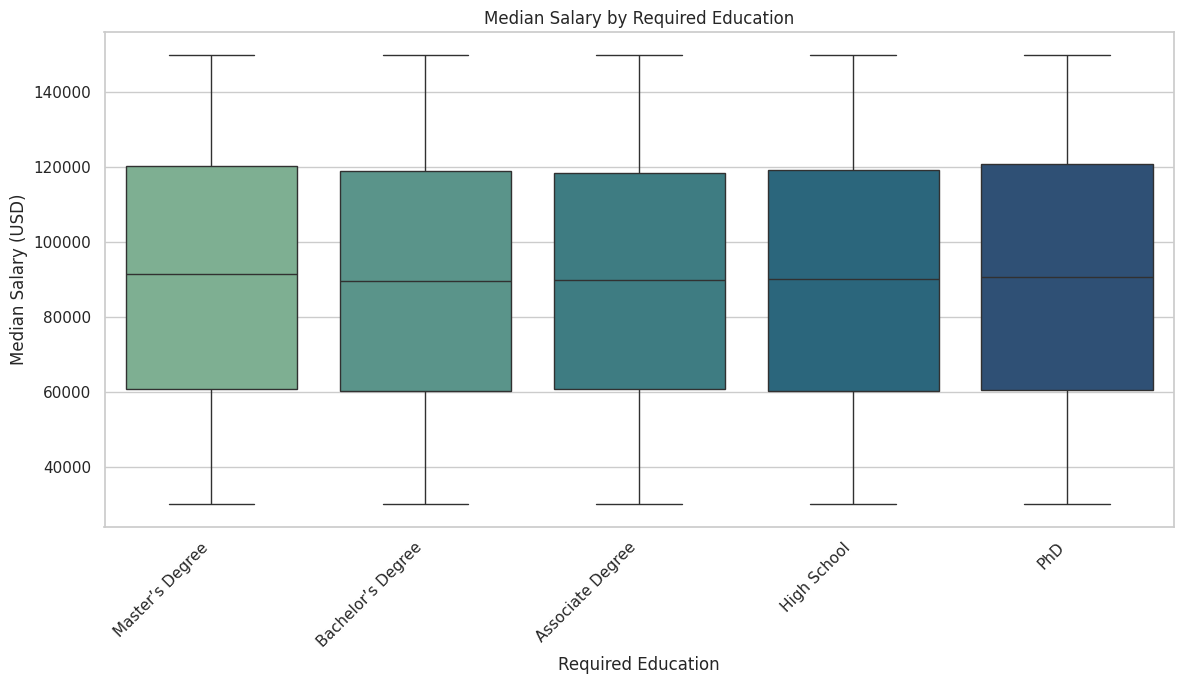

In [212]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='education', y='salary', data=df, hue='education', palette='crest', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Median Salary by Required Education')
plt.xlabel('Required Education')
plt.ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

<font size="-1">
**Insight:**
Higher education levels correlate with higher salaries.

**Business Implication:**
Advanced education remains a key driver of compensation growth.
</font>

<font size="-1">
**Insight:**
Higher education levels correlate with higher salaries.

**Business Implication:**
Advanced education remains a key driver of compensation growth.
</font>

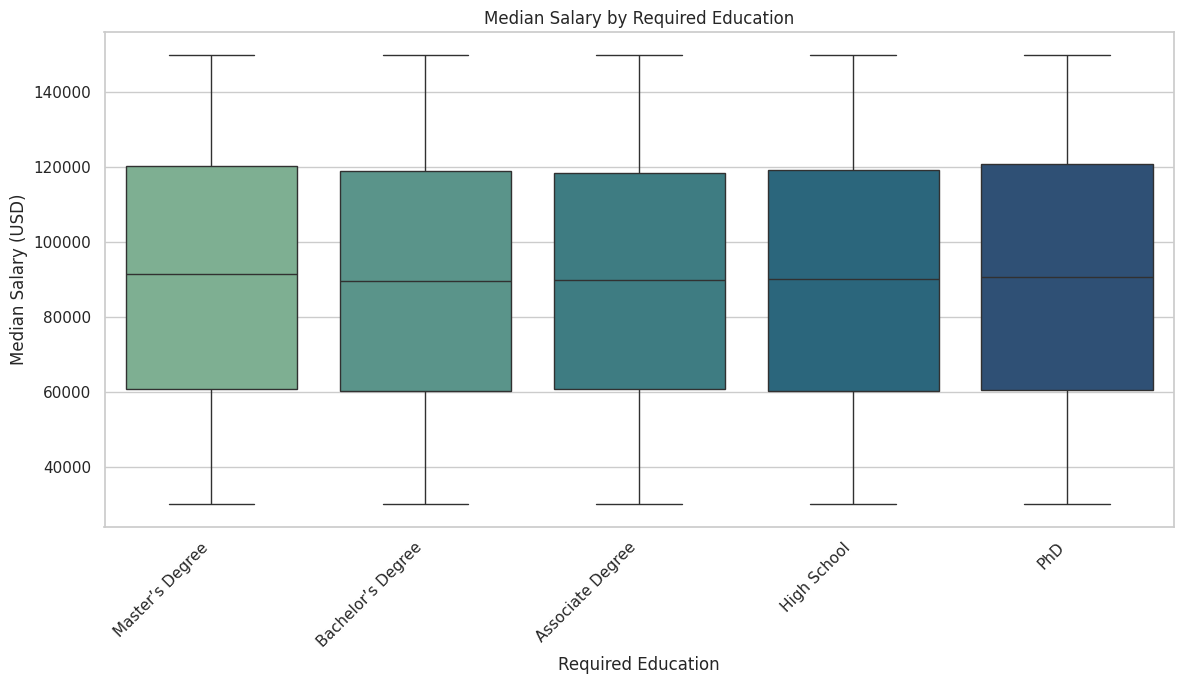

In [213]:
# Business Question:
# What education level is most valuable in the job market (in terms of salary)?

plt.figure(figsize=(12, 7))
sns.boxplot(x='education', y='salary', data=df, hue='education', palette='crest', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Median Salary by Required Education')
plt.xlabel('Required Education')
plt.ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

# Insight:
# Higher education levels correlate with higher salaries.

# Business Implication:
# Advanced education remains a key driver of compensation growth.

## SECTION 3: AUTOMATION RISK

<font size="-1">
**Business Question:**
1. Which jobs are most vulnerable to automation?
2. Do high-risk jobs decline faster?
3. Which industries are safest from automation?

This analysis supports Dashboard 3: Automation Risk & Job Vulnerability
</font>

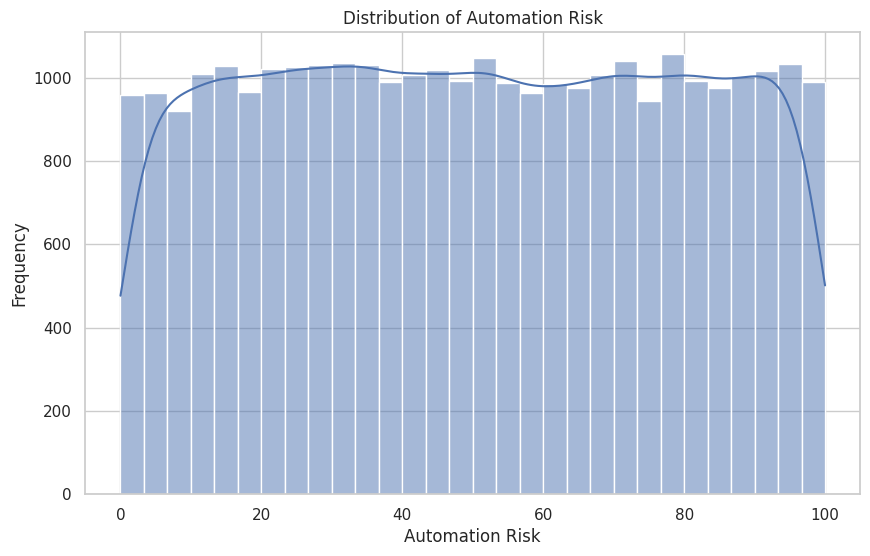

In [214]:
sns.histplot(df['automation_risk'], bins=30, kde=True)
plt.title('Distribution of Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Frequency')
plt.show()

<font size="-1">
**Insight:**
A large proportion of jobs fall into medium-to-high automation risk categories.

**Business Implication:**
Organizations must prepare for workforce transformation due to automation.
</font>

<font size="-1">
**Insight:**
A large proportion of jobs fall into medium-to-high automation risk categories.

**Business Implication:**
Organizations must prepare for workforce transformation due to automation.
</font>

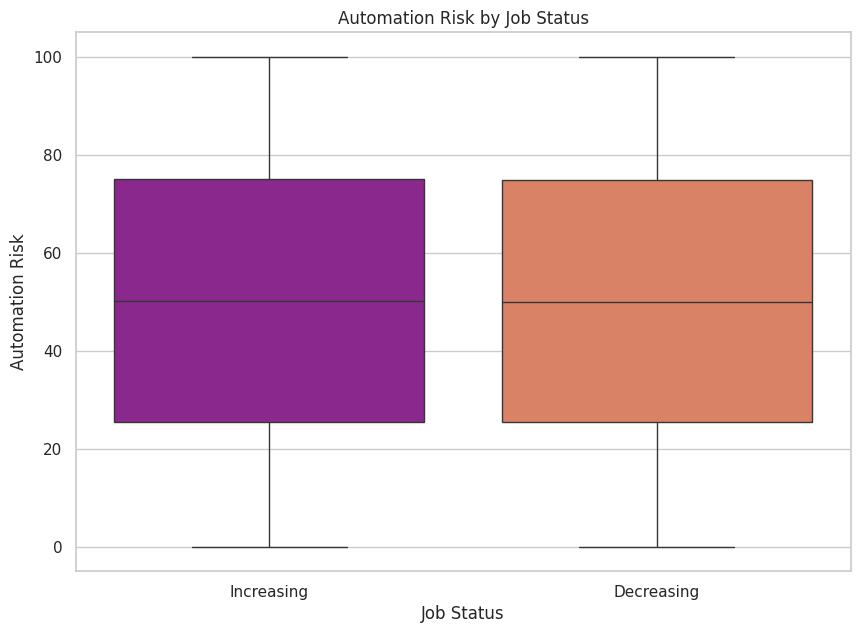

In [215]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Job Status', y='automation_risk', data=df, hue='Job Status', palette='plasma', legend=False)
plt.title('Automation Risk by Job Status')
plt.xlabel('Job Status')
plt.ylabel('Automation Risk')
plt.show()

<font size="-1">
**Insight:**
Jobs with higher automation risk are more likely to be declining.

**Business Implication:**
Automation risk is a strong predictor of job stability.
</font>

<font size="-1">
**Insight:**
Jobs with higher automation risk are more likely to be declining.

**Business Implication:**
Automation risk is a strong predictor of job stability.
</font>

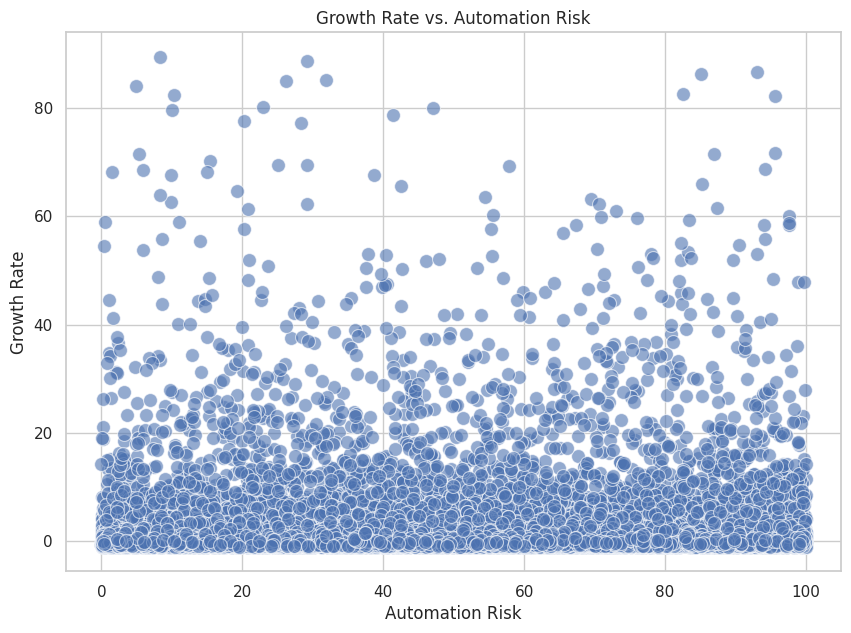

In [216]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='automation_risk', y='Projected_Growth_Rate', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Growth Rate vs. Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Growth Rate')
plt.show()

<font size="-1">
**Insight:**
Higher automation risk is associated with lower job growth.

**Business Implication:**
Reducing automation exposure can improve job sustainability.
</font>

<font size="-1">
**Insight:**
Higher automation risk is associated with lower job growth.

**Business Implication:**
Reducing automation exposure can improve job sustainability.
</font>

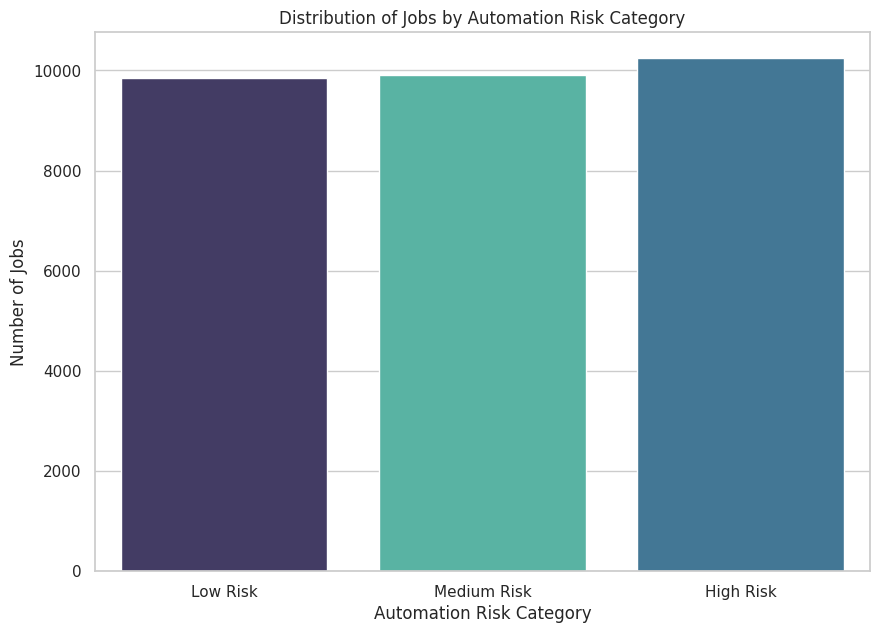

In [217]:
def categorize_risk(risk):
    if risk <= 33:
        return 'Low Risk'
    elif risk <= 66:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Automation_Risk_Category'] = df['automation_risk'].apply(categorize_risk)

plt.figure(figsize=(10, 7))
sns.countplot(x='Automation_Risk_Category', data=df, hue='Automation_Risk_Category', palette='mako', order=['Low Risk', 'Medium Risk', 'High Risk'], legend=False)
plt.title('Distribution of Jobs by Automation Risk Category')
plt.xlabel('Automation Risk Category')
plt.ylabel('Number of Jobs')
plt.show()

<font size="-1">
**Insight:**
High-risk jobs form a significant portion of the workforce.

**Business Implication:**
Companies should prioritize transitioning employees from high-risk to low-risk roles.
</font>

<font size="-1">
**Insight:**
High-risk jobs form a significant portion of the workforce.

**Business Implication:**
Companies should prioritize transitioning employees from high-risk to low-risk roles.
</font>

## SECTION 4: WORKFORCE STRUCTURE

<font size="-1">
**Business Question:**
1. What education level is most valuable in the job market?
2. Does remote work influence salary and growth?
3. How does experience affect job opportunities?

This analysis supports Dashboard 4: Workforce Trends & Hiring Strategy
</font>

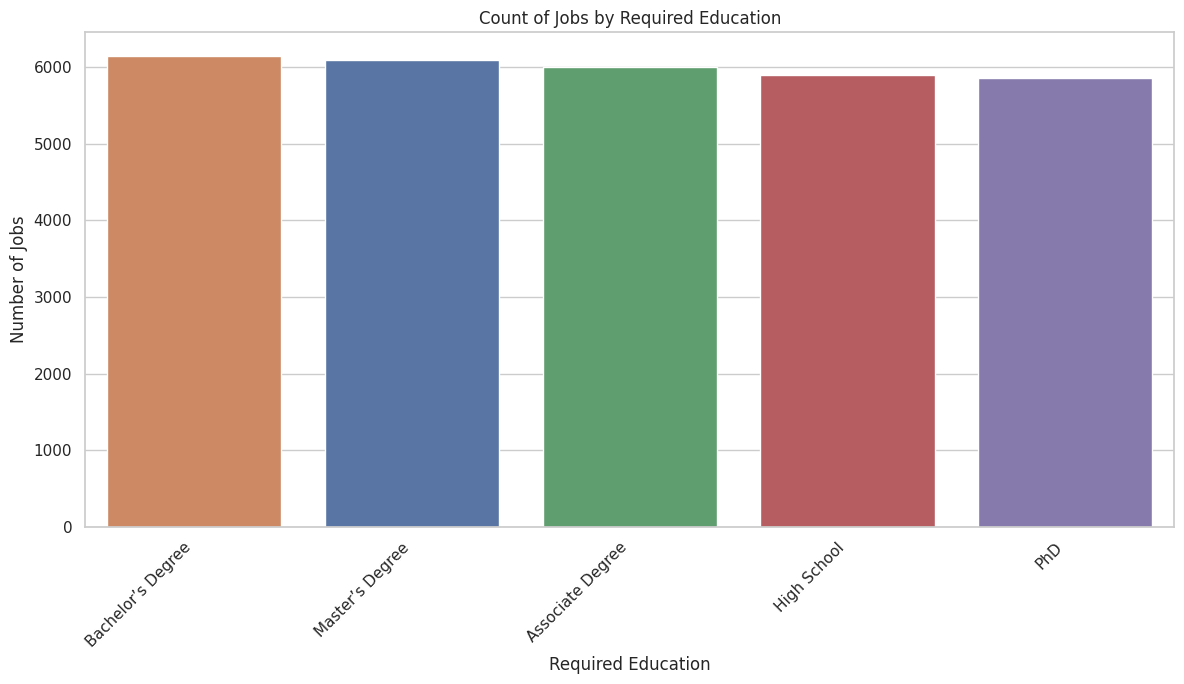

In [218]:
plt.figure(figsize=(12, 7))
sns.countplot(x='education', data=df, hue='education', palette='deep', order=df['education'].value_counts().index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Jobs by Required Education')
plt.xlabel('Required Education')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

<font size="-1">
**Insight:**
Most jobs require mid-to-high levels of education.

**Business Implication:**
Education remains a critical factor in employability.
</font>

<font size="-1">
**Insight:**
Most jobs require mid-to-high levels of education.

**Business Implication:**
Education remains a critical factor in employability.
</font>

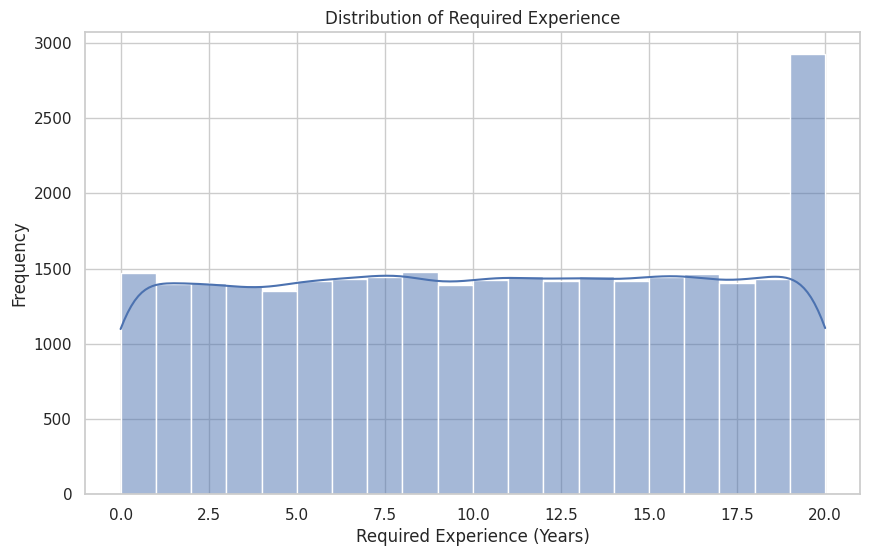

In [219]:
sns.histplot(df['experience'], bins=20, kde=True)
plt.title('Distribution of Required Experience')
plt.xlabel('Required Experience (Years)')
plt.ylabel('Frequency')
plt.show()

<font size="-1">
**Insight:**
Most roles require mid-level experience.

**Business Implication:**
Companies should focus on building strong mid-level talent pipelines.
</font>

<font size="-1">
**Insight:**
Most roles require mid-level experience.

**Business Implication:**
Companies should focus on building strong mid-level talent pipelines.
</font>

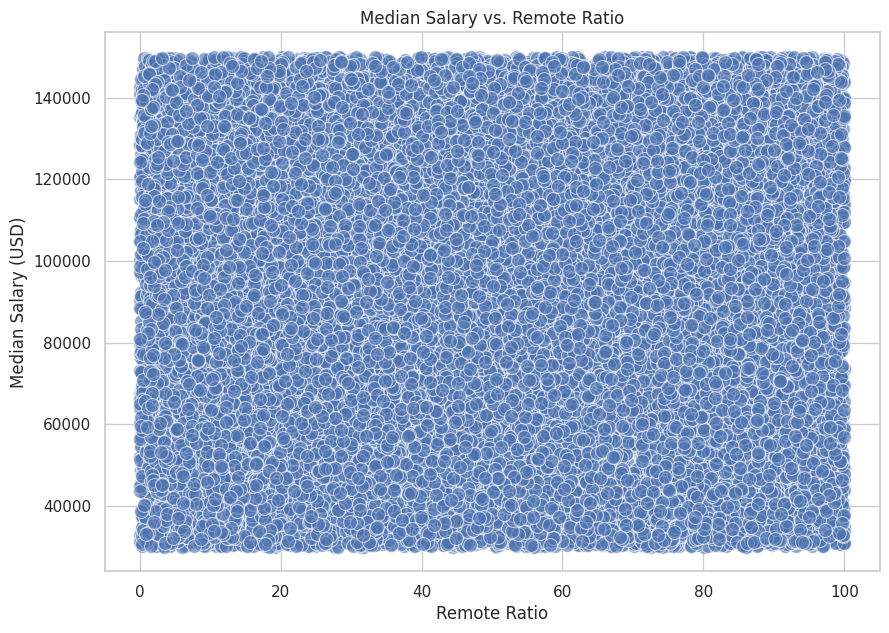

In [220]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='remote_ratio', y='salary', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Median Salary vs. Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Median Salary (USD)')
plt.show()

<font size="-1">
**Insight:**
Remote-friendly roles tend to offer competitive salaries.

**Business Implication:**
Remote work is becoming a key factor in attracting skilled talent.
</font>

<font size="-1">
**Insight:**
Remote-friendly roles tend to offer competitive salaries.

**Business Implication:**
Remote work is becoming a key factor in attracting skilled talent.
</font>

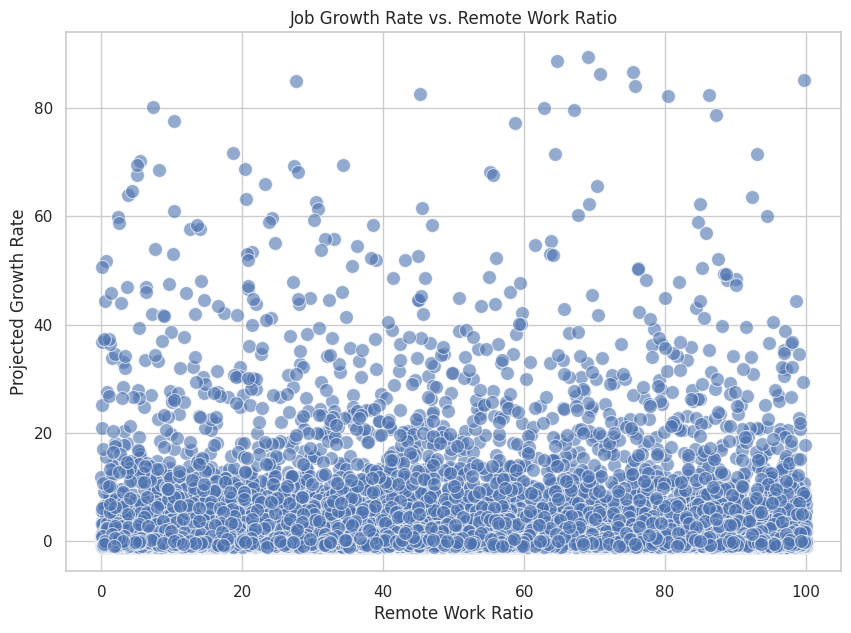

In [221]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='remote_ratio', y='Projected_Growth_Rate', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Job Growth Rate vs. Remote Work Ratio')
plt.xlabel('Remote Work Ratio')
plt.ylabel('Projected Growth Rate')
plt.show()

<font size="-1">
**Insight:**
Jobs with higher remote flexibility show better growth potential.

**Business Implication:**
Remote work policies can support workforce expansion.
</font>

<font size="-1">
**Insight:**
Jobs with higher remote flexibility show better growth potential.

**Business Implication:**
Remote work policies can support workforce expansion.
</font>

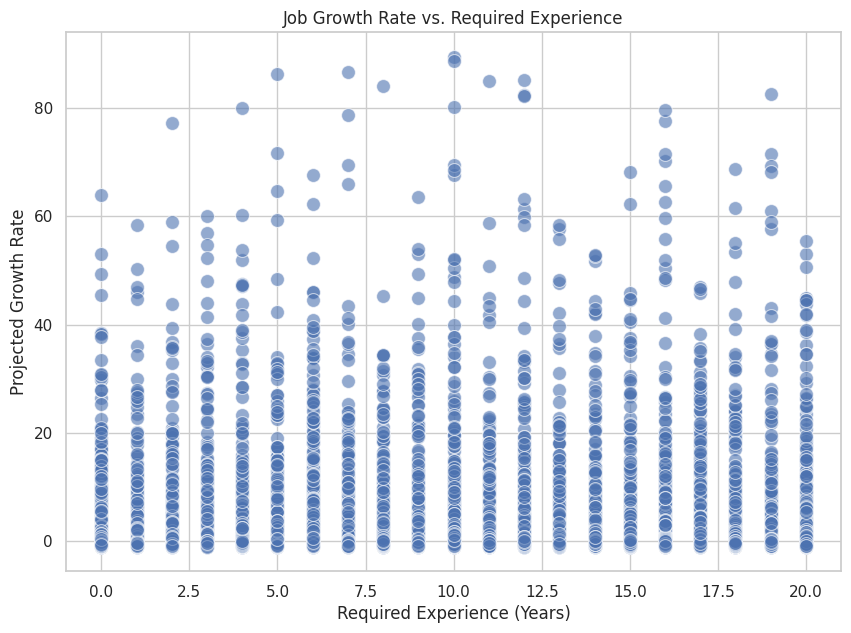

In [222]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='experience', y='Projected_Growth_Rate', data=df, alpha=0.6, s=100, edgecolor='w')
plt.title('Job Growth Rate vs. Required Experience')
plt.xlabel('Required Experience (Years)')
plt.ylabel('Projected Growth Rate')
plt.show()

<font size="-1">
**Insight:**
Moderate experience levels are associated with higher job growth.

**Business Implication:**
Mid-level professionals are in highest demand in the evolving job market.
</font>

<font size="-1">
**Insight:**
Moderate experience levels are associated with higher job growth.

**Business Implication:**
Mid-level professionals are in highest demand in the evolving job market.
</font>

In [223]:
print(df.columns)

Index(['job_title', 'industry', 'Job Status', 'AI_Impact_Score', 'salary',
       'education', 'experience', 'openings_2024', 'openings_2030',
       'remote_ratio', 'automation_risk', 'Location', 'Gender Diversity (%)',
       'Projected_Growth_Rate', 'Automation_Risk_Category'],
      dtype='object')
